# Crop Dataset Cleaning and Preprocessing

This notebook cleans and preprocesses the crop recommendation dataset for multi-class classification with reproducible settings (`random_state=42`).

In [1]:
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
RANDOM_STATE = 42
ROOT = Path('..').resolve()
RAW_PATH = ROOT / 'data' / 'raw' / 'crop_recomandation.csv'
PROCESSED_DIR = ROOT / 'data' / 'processed'
MODELS_DIR = ROOT / 'models'
OUTPUTS_DIR = ROOT / 'outputs'
for path in [PROCESSED_DIR, MODELS_DIR, OUTPUTS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

In [2]:
df = pd.read_csv(RAW_PATH)
print('Shape:', df.shape)
display(df.head())
display(df.info())
display(df.describe(include='all').T.head(20))
missing = (df.isna().mean() * 100).sort_values(ascending=False)
display(missing[missing > 0].to_frame('missing_pct'))

Shape: (102675, 25)


,State_Name,Season,N,P,K,rainfall,humidity,temperature,Crop Yield (kg per hectare),Rainfall_Temperature,...,Soil_Type,Irrigation_Method,Fertilizer_Used_kg,Pesticide_Usage_kg,Soil_Moisture,Sunshine_hours,Wind_speed,Altitude_m,Organic_Carbon,Soil_Texture
0,Kerala,Whole Year,41,92,54,2917.102941,66.83,32.60,3324.563123,95097.555877,...,Neutral,Rainfed,170.78,9.58,50.96,4.25,9.55,409.74,0.38,Clay
1,West Bengal,Whole Year,35,9,83,852.525083,48.47,25.67,5471.575701,21884.318891,...,Neutral,Sprinkler,91.18,11.47,35.98,7.19,15.93,310.58,0.63,Clay
2,Assam,Whole Year,42,6,23,1152.740698,76.53,17.61,1734.917776,20299.763692,...,Neutral,Drip,172.09,13.42,48.97,5.79,8.85,10.00,0.86,Sandy
3,Meghalaya,Whole Year,116,37,136,1228.057333,32.12,36.37,4438.622051,44664.445201,...,Neutral,Rainfed,98.29,8.71,25.21,7.06,5.69,412.56,0.54,Loamy
4,Kerala,Whole Year,1,5,54,953.706476,69.97,18.59,2478.063851,17729.403389,...,Neutral,Rainfed,152.09,11.00,46.73,8.63,7.47,521.29,0.82,Clay


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102675 entries, 0 to 102674
Data columns (total 25 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   State_Name                   102675 non-null  object 
 1   Season                       102675 non-null  object 
 2   N                            102675 non-null  int64  
 3   P                            102675 non-null  int64  
 4   K                            102675 non-null  int64  
 5   rainfall                     102675 non-null  float64
 6   humidity                     102675 non-null  float64
 7   temperature                  102675 non-null  float64
 8   Crop Yield (kg per hectare)  102675 non-null  float64
 9   Rainfall_Temperature         102675 non-null  float64
 10  Humidity_Temperature         102675 non-null  float64
 11  NPK_Ratio                    102675 non-null  float64
 12  Weather_Index                102675 non-null  float64
 13 

None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
State_Name,102675,33,Tamil Nadu,18575,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Season,102675,6,Whole Year,48196,NaN,NaN,NaN,NaN,NaN,NaN,NaN
N,102675.0,NaN,NaN,NaN,71.060823,39.69895,0.0,38.0,68.0,107.0,139.0
P,102675.0,NaN,NaN,NaN,51.502995,26.53518,5.0,28.0,53.0,74.0,99.0
K,102675.0,NaN,NaN,NaN,76.307592,41.479081,5.0,42.0,78.0,112.0,149.0
rainfall,102675.0,NaN,NaN,NaN,1682.253215,789.656256,400.085492,987.094788,1683.347473,2426.116024,2999.630524
humidity,102675.0,NaN,NaN,NaN,59.636061,17.049082,30.0,44.52,59.14,73.825,90.0
temperature,102675.0,NaN,NaN,NaN,27.55532,7.175358,15.01,21.82,27.36,33.9,40.0
Crop Yield (kg per hectare),102675.0,NaN,NaN,NaN,3448.164878,1497.74294,800.123554,2138.634719,3488.298119,4702.90684,5999.323801
Rainfall_Temperature,102675.0,NaN,NaN,NaN,46430.120767,25720.799442,6170.123069,25250.211187,42366.594078,63913.071079,119249.622239


,missing_pct


## 1) Schema Alignment and Invalid Value Checks

The objective target is treated as `label` when present; otherwise `Crop` is used.
For core agronomic predictors, we enforce domain ranges and convert invalid values to NaN before imputation.

In [3]:
df = df.copy()
target_col = 'label' if 'label' in df.columns else ('Crop' if 'Crop' in df.columns else None)
if target_col is None:
    raise ValueError('No crop target column found. Expected label or Crop.')

candidate_features = ['N', 'P', 'K', 'temperature', 'humidity', 'pH', 'ph', 'rainfall']
available_features = [c for c in candidate_features if c in df.columns]
ph_col = 'pH' if 'pH' in df.columns else ('ph' if 'ph' in df.columns else None)
if ph_col and ph_col != 'pH':
    df['pH'] = df[ph_col]

required = ['N', 'P', 'K', 'temperature', 'humidity', 'pH', 'rainfall']
missing_required = [c for c in required if c not in df.columns]
if missing_required:
    raise ValueError(f'Missing required columns for crop modeling: {missing_required}')

range_rules = {
    'N': (0, 300),
    'P': (0, 300),
    'K': (0, 300),
    'temperature': (-10, 60),
    'humidity': (0, 100),
    'pH': (0, 14),
    'rainfall': (0, 10000),
}

for col, (low, high) in range_rules.items():
    invalid_mask = (df[col] < low) | (df[col] > high)
    if invalid_mask.any():
        print(f'{col}: replacing {invalid_mask.sum()} invalid values with NaN')
        df.loc[invalid_mask, col] = np.nan

In [4]:
work_df = df[required + [target_col]].copy()
numeric_cols = required
categorical_cols = [target_col]

missing_pct = work_df.isna().mean() * 100
drop_cols = missing_pct[missing_pct > 20].index.tolist()
if drop_cols:
    print('Dropping columns (>20% missing):', drop_cols)
    work_df = work_df.drop(columns=drop_cols)
    numeric_cols = [c for c in numeric_cols if c not in drop_cols]

# Numeric imputation strategy:
# <=5% missing -> KNN imputer for local structure preservation
# >5% missing -> median for robust central tendency
low_missing_num = [c for c in numeric_cols if 0 < missing_pct[c] <= 5]
high_missing_num = [c for c in numeric_cols if missing_pct[c] > 5]

if low_missing_num:
    knn = KNNImputer(n_neighbors=5)
    work_df[low_missing_num] = knn.fit_transform(work_df[low_missing_num])

for col in high_missing_num:
    work_df[col] = work_df[col].fillna(work_df[col].median())

for col in categorical_cols:
    if col in work_df.columns:
        mode = work_df[col].mode(dropna=True)
        fill_val = mode.iloc[0] if len(mode) else 'missing'
        work_df[col] = work_df[col].fillna(fill_val)

display((work_df.isna().mean() * 100).to_frame('missing_pct_after'))

,missing_pct_after
N,0.0
P,0.0
K,0.0
temperature,0.0
humidity,0.0
pH,0.0
rainfall,0.0
Crop,0.0


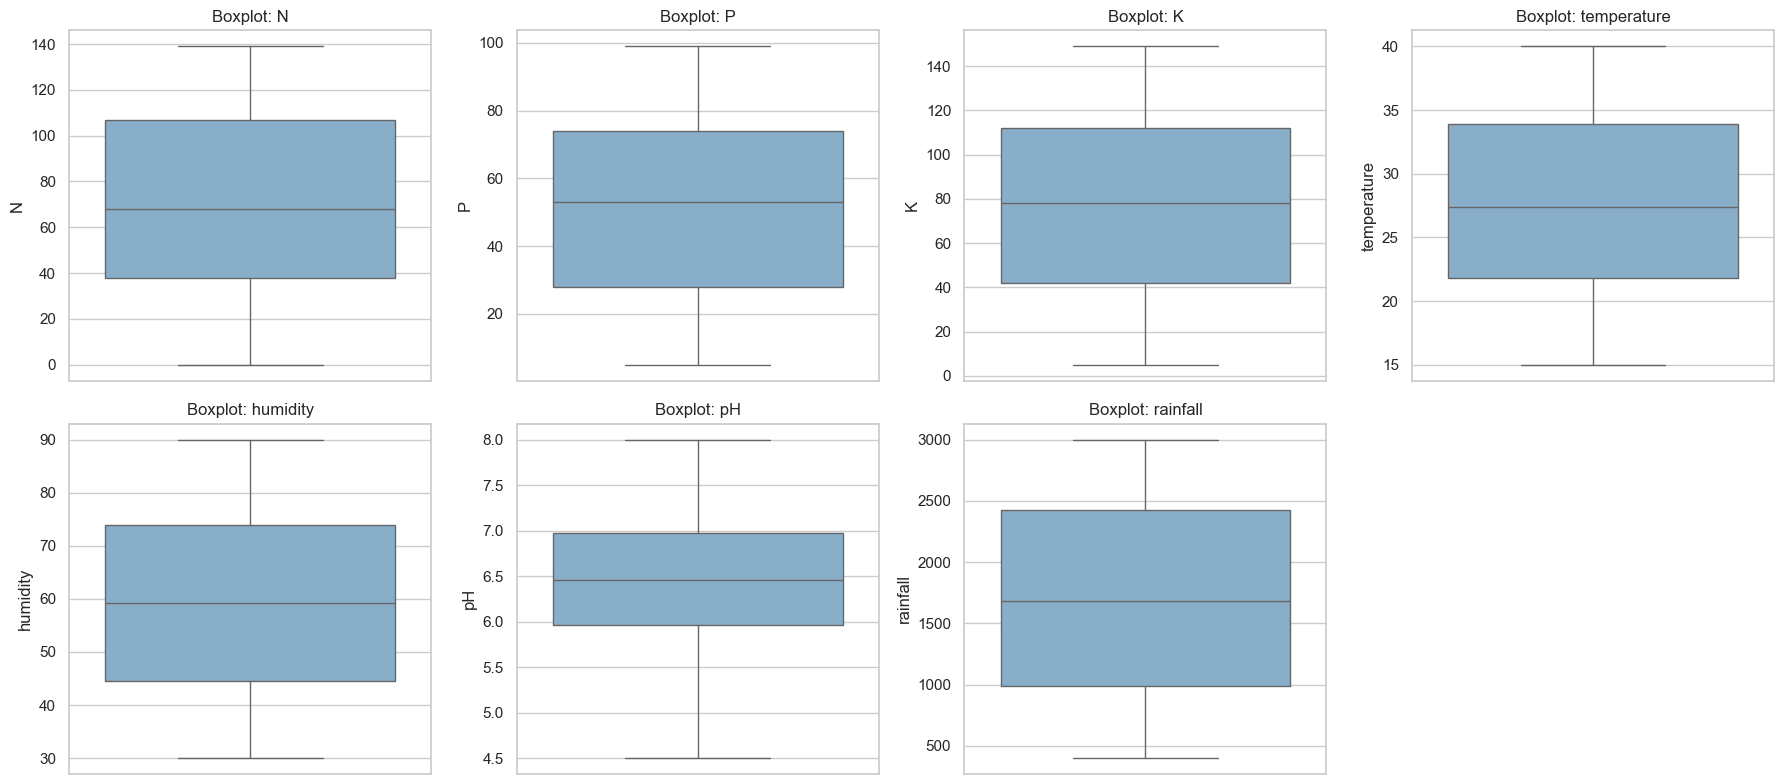

,zscore_outliers_gt3
pH,168
P,0
N,0
K,0
temperature,0
humidity,0
rainfall,0


In [8]:
from scipy.stats import zscore

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for idx, col in enumerate(numeric_cols):
    sns.boxplot(y=work_df[col], ax=axes[idx], color='#7eb0d5')
    axes[idx].set_title(f'Boxplot: {col}')
for j in range(len(numeric_cols), len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()

outlier_counts = {}
for col in numeric_cols:
    z_vals = np.abs(zscore(work_df[col], nan_policy='omit'))
    outlier_counts[col] = int((z_vals > 3).sum())
outlier_counts = pd.Series(outlier_counts).sort_values(ascending=False)
display(outlier_counts.to_frame('zscore_outliers_gt3'))

# Capping (winsorization) to reduce extreme influence while retaining records
for col in numeric_cols:
    q1 = work_df[col].quantile(0.25)
    q3 = work_df[col].quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    work_df[col] = work_df[col].clip(low, high)

In [6]:
X = work_df[numeric_cols].copy()
y = work_df[target_col].copy()

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=RANDOM_STATE, stratify=y_encoded
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pd.DataFrame(X_train, columns=numeric_cols).to_csv(PROCESSED_DIR / 'crop_X_train.csv', index=False)
pd.DataFrame(X_test, columns=numeric_cols).to_csv(PROCESSED_DIR / 'crop_X_test.csv', index=False)
pd.Series(y_train, name='target').to_csv(PROCESSED_DIR / 'crop_y_train.csv', index=False)
pd.Series(y_test, name='target').to_csv(PROCESSED_DIR / 'crop_y_test.csv', index=False)
pd.DataFrame(X_train_scaled, columns=numeric_cols).to_csv(PROCESSED_DIR / 'crop_X_train_scaled.csv', index=False)
pd.DataFrame(X_test_scaled, columns=numeric_cols).to_csv(PROCESSED_DIR / 'crop_X_test_scaled.csv', index=False)

joblib.dump(label_encoder, MODELS_DIR / 'crop_label_encoder.joblib')
joblib.dump(scaler, MODELS_DIR / 'crop_standard_scaler.joblib')

print('Train shape:', X_train.shape, 'Test shape:', X_test.shape)
print('Artifacts saved in data/processed and models directories.')

Train shape: (82140, 7) Test shape: (20535, 7)
Artifacts saved in data/processed and models directories.


## Rationale Summary

- Invalid agronomic readings are set to NaN before imputation.
- Numeric missing values use KNN for low missingness and median for higher missingness.
- Outliers are capped via IQR winsorization to preserve observations while limiting skew impact.
- Labels are integer-encoded using LabelEncoder for model compatibility.
- Scaling is fit only on training data to prevent leakage.